In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

FRAC_BITS = 32
FRAC_ONE  = 1 << FRAC_BITS

N = 1024

In [2]:
def assert_u32(x):
    assert 0 <= x <= 0xFFFFFFFF

def u32(x: int) -> int:
    return x & 0xFFFFFFFF

def u32_to_unit_float(x_u32: int) -> float:
    return u32(x_u32) / float(FRAC_ONE)

def reverse_bits(x: int, nbits = FRAC_BITS):
    # assumes x is already 32 bit
    out = 0
    for _ in range(nbits):
        out <<= 1
        out  |= (x & 1)
        x   >>= 1
    return u32(out)

def normalize(v):
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    if n == 0.0:
        return v
    return v / n

In [3]:
def sobol_direction_numbers_2d(frac_bits = FRAC_BITS):
    """
    Returns a (2, frac_bits) array:
    - dim 0: standard v[k] = 1 << (31-k)
    - dim 1: based on primitive polynomial x^2 + x + 1
    """
    V = np.zeros((2, frac_bits), dtype=np.uint32)

    # --- dimension 0 ---
    for k in range(frac_bits):
        V[0, k] = np.uint32(1 << (frac_bits - 1 - k))

    # --- dimension 1 ---
    # primitive polynomial: x^2 + x + 1  → degree s=2
    s = 2
    a = 1        # coefficients for x^1 and x^0 terms
    m = [1, 3]   # initial direction numbers in integer form

    # load initial m's
    for i in range(s):
        V[1, i] = np.uint32(u32(m[i] << (frac_bits - 1 - i)))

    # recurrence
    for i in range(s, frac_bits):
        # start: v[i] = v[i-s] ^ (v[i-s] >> s)
        val = u32(int(V[1, i - s])) ^ u32(int(V[1, i - s]) >> s)

        # then conditionally xor terms based on bits of a_mask
        # for j=1..s-1, test bit (s-1-j)
        for j in range(1, s):
            if (a >> (s - 1 - j)) & 1:
                val ^= u32(int(V[1, i - j]) >> j)

        V[1, i] = np.uint32(u32(val))

    return V

def sobol_u32_stateless(dim: int, index: int, dir_table: np.ndarray) -> int:
    index = u32(index)
    g = index ^ (index >> 1)
    x = 0
    bit = 0
    num_bits = dir_table.shape[1] # should be
    
    while g and bit < num_bits:
        if g & 1:
            x ^= int(dir_table[dim][bit])
        g  >>= 1
        bit += 1
    return u32(x)

def sobol_float_stateless(dim: int, index: int, dir_table: np.ndarray) -> int:
    return sobol_u32_stateless(dim, index, dir_table) / float(FRAC_ONE)

In [4]:
for i, vals in enumerate(sobol_direction_numbers_2d()):
    print("DIMENSON", i)
    for j in range(0,len(vals),4):
        print(f"V[{j}]=32'h{hex(vals[j])[2:]}; V[{j+1}]=32'h{hex(vals[j+1])[2:]}; V[{j+2}]=32'h{hex(vals[j+2])[2:]}; V[{j+3}]=32'h{hex(vals[j+3])[2:]};")
        

DIMENSON 0
V[0]=32'h80000000; V[1]=32'h40000000; V[2]=32'h20000000; V[3]=32'h10000000;
V[4]=32'h8000000; V[5]=32'h4000000; V[6]=32'h2000000; V[7]=32'h1000000;
V[8]=32'h800000; V[9]=32'h400000; V[10]=32'h200000; V[11]=32'h100000;
V[12]=32'h80000; V[13]=32'h40000; V[14]=32'h20000; V[15]=32'h10000;
V[16]=32'h8000; V[17]=32'h4000; V[18]=32'h2000; V[19]=32'h1000;
V[20]=32'h800; V[21]=32'h400; V[22]=32'h200; V[23]=32'h100;
V[24]=32'h80; V[25]=32'h40; V[26]=32'h20; V[27]=32'h10;
V[28]=32'h8; V[29]=32'h4; V[30]=32'h2; V[31]=32'h1;
DIMENSON 1
V[0]=32'h80000000; V[1]=32'hc0000000; V[2]=32'hc0000000; V[3]=32'h90000000;
V[4]=32'hb8000000; V[5]=32'he8000000; V[6]=32'he2000000; V[7]=32'ha3000000;
V[8]=32'h8b000000; V[9]=32'hce400000; V[10]=32'hcee00000; V[11]=32'h9aa00000;
V[12]=32'hb0080000; V[13]=32'he40c0000; V[14]=32'hee0c0000; V[15]=32'haa090000;
V[16]=32'h808b8000; V[17]=32'hc0ce8000; V[18]=32'hc0ce2000; V[19]=32'h909a3000;
V[20]=32'hb8b0b000; V[21]=32'he8e4e400; V[22]=32'he2eeee00; V[23]=32'h

In [5]:
def rotl32(x: int, r: int) -> int:
    x = u32(x)
    return u32((x<<r) | (x>>(32-r)))

def fmix32(h: int) -> int:
    h  = u32(h)
    h ^= (h >> 16)
    h  = u32(h * 0x85ebca6b)
    h ^= (h >> 13)
    h  = u32(h * 0xc2b2ae35)
    h ^= (h >> 16)
    return u32(h)

def mix(h: int, k: int) -> int:
    # MurmurHash3 32-bit block mix
    h = u32(h)
    k = u32(k)

    k = u32(k * 0xcc9e2d51)
    k = rotl32(k, 15)
    k = u32(k * 0x1b873593)

    h ^= k
    h = rotl32(h, 13)
    h = u32(h * 5 + 0xe6546b64)
    return u32(h)
    
def hash_combine(*vals: int) -> int:
    if len(vals) == 0: raise ValueError("hash_combine needs at least 1 value")
    h0 = 0x9747b28c
    h = reduce(mix, (u32(v) for v in vals), u32(h0))
    return fmix32(h)

In [6]:
def test_hash_combine_determinism_and_order(hash_combine):
    a = hash_combine(1,2,3)
    b = hash_combine(1,2,3)
    c = hash_combine(3,2,1)
    assert a == b
    assert a != c
    assert_u32(a); assert_u32(c)
    
def test_hash_combine_small_inputs(hash_combine):
    seed_base = hash_combine(123, 0, 0)     # pixel, frame, bounce
    s0 = hash_combine(seed_base, 0)
    s1 = hash_combine(seed_base, 1)
    assert s0 != s1

test_hash_combine_determinism_and_order(hash_combine)
test_hash_combine_small_inputs(hash_combine)

In [7]:
def laine_karras_permutation(x: int, seed: int) -> int:
    x  = u32(x + seed)
    x ^= u32(x * 0x6c50b47c)
    x ^= u32(x * 0xb82f1e52)
    x ^= u32(x * 0xc7afe638)
    x ^= u32(x * 0x8d22f6e6)
    return x

def nested_uniform_scramble(x: int, seed: int):
    x = reverse_bits(x)
    x = laine_karras_permutation(x, seed)
    x = reverse_bits(x)
    return x

def shuffled_scrambled_sobol2d(index: int, seed: int):
    direction_table_2d = sobol_direction_numbers_2d()
    
    index = nested_uniform_scramble(index, seed)
    s0 = sobol_u32_stateless(0, index, direction_table_2d)
    s1 = sobol_u32_stateless(1, index, direction_table_2d)
    
    u0 = nested_uniform_scramble(s0, hash_combine(seed, 0))
    u1 = nested_uniform_scramble(s1, hash_combine(seed, 1))
    return u0, u1

In [8]:
def test_nus_is_permutation(nus_u32):
    seed = 0xDEADBEEF
    vals = [nus_u32(i, seed) for i in range(5000)]
    assert len(set(vals)) == len(vals)  # injective on small set

def test_nus_determinism(nus_u32):
    seed = 12345
    x = 0x12345678
    assert nus_u32(x, seed) == nus_u32(x, seed)
    assert nus_u32(x, seed) != nus_u32(x, seed+1)

def test_shuf_scr_determinism(shuf_scr_2d):
    seed_base = 0xA5A5A5A5
    u0a,u1a = shuf_scr_2d(17, seed_base)
    u0b,u1b = shuf_scr_2d(17, seed_base)
    assert (u0a,u1a) == (u0b,u1b)

def test_shuf_scr_changes_with_seed(shuf_scr_2d, hash_combine):
    pixel, frame = 123, 0
    seed0 = hash_combine(pixel, frame, 0)  # bounce=0
    seed1 = hash_combine(pixel, frame, 1)  # bounce=1
    u0a,u1a = shuf_scr_2d(17, seed0)
    u0b,u1b = shuf_scr_2d(17, seed1)
    assert (u0a,u1a) != (u0b,u1b), f"should not be equal.. {u0a, u1a} & {u0b, u1b}"

def test_shuf_scr_distribution(shuf_scr_2d, hash_combine):
    pixel, frame, bounce = 123, 0, 0
    seed_base = hash_combine(pixel, frame, bounce)
    N = 20000
    us = np.empty(N, dtype=np.float64)
    vs = np.empty(N, dtype=np.float64)
    for i in range(N):
        u0,u1 = shuf_scr_2d(i, seed_base)
        us[i] = u32_to_unit_float(u0)
        vs[i] = u32_to_unit_float(u1)
    assert 0.0 <= us.min() < 1.0 and 0.0 < us.max() < 1.0
    assert 0.45 < us.mean() < 0.55
    assert 0.45 < vs.mean() < 0.55

test_nus_is_permutation(nested_uniform_scramble)
test_nus_determinism(nested_uniform_scramble)
test_shuf_scr_determinism(shuffled_scrambled_sobol2d)
test_shuf_scr_changes_with_seed(shuffled_scrambled_sobol2d, hash_combine)
test_shuf_scr_distribution(shuffled_scrambled_sobol2d, hash_combine)

In [9]:
def sample_ggx_vndf(u1, u2, V, roughness):
    """
    GGX VNDF sampling (Heitz).
    Inputs:
      u1,u2 in [0,1)
      V: view direction in tangent space (3,)
      alpha: GGX alpha (roughness^2)
    Output:
      m: microfacet normal in tangent space (3,)
    """
    view = normalize(np.array(V, dtype=np.float64))
    alpha = float(roughness) * float(roughness)
    
    # transform view direction to hemisphere configuration
    Vh = normalize(np.array([alpha*view[0], alpha*view[1], view[2]], dtype=np.float64))
    
    # orthonormal basis
    lensq = Vh[0]*Vh[0] + Vh[1]*Vh[1]
    if lensq > 1e-20:
        inv_len = 1.0 / np.sqrt(lensq)
        T1 = np.array([-Vh[1]*inv_len, Vh[0]*inv_len, 0.0], dtype=np.float64)
        T2 = np.cross(Vh, T1)
    else:
        T1 = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        T2 = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        
    # parameterization of projected area + sampling
    r = np.sqrt(u1)
    phi = 2.0 * np.pi * u2
    t1 = r * np.cos(phi)
    t2 = r * np.sin(phi)
    
    s = 0.5 * (1.0 + Vh[2])
    t2 = (1.0 - s) * np.sqrt(max(0.0, 1.0 - t1*t1)) + s * t2
    
    # reprojection onto hemisphere
    Nh = t1*T1 + t2*T2 + np.sqrt(max(0.0, 1.0 - t1*t1 - t2*t2)) * Vh
    
    # transform normal back to ellipsoid configuration
    N = normalize([alpha * Nh[0], alpha* Nh[1], max(0.0, Nh[2])])
    return N

def ggx_sample_from_u32(u0_u32, u1_u32, V, alpha):
    u1 = u32_to_unit_float(u0_u32)
    u2 = u32_to_unit_float(u1_u32)
    return sample_ggx_vndf(u1, u2, V, alpha)

In [ ]:
# CPU OPTIMIZED HELPERS FOR GGX BENCHMARK
import math

INV_FRAC_ONE = 1.0 / float(FRAC_ONE)

def reverse_bits32_fast(x: int) -> int:
    x = u32(x)
    x = ((x >> 1) & 0x55555555) | ((x & 0x55555555) << 1)
    x = ((x >> 2) & 0x33333333) | ((x & 0x33333333) << 2)
    x = ((x >> 4) & 0x0F0F0F0F) | ((x & 0x0F0F0F0F) << 4)
    x = ((x >> 8) & 0x00FF00FF) | ((x & 0x00FF00FF) << 8)
    x = ((x >> 16) | (x << 16))
    return u32(x)

def nested_uniform_scramble_fast(x: int, seed: int) -> int:
    x = reverse_bits32_fast(x)
    x = u32(x + seed)
    x ^= u32(x * 0x6C50B47C)
    x ^= u32(x * 0xB82F1E52)
    x ^= u32(x * 0xC7AFE638)
    x ^= u32(x * 0x8D22F6E6)
    x = reverse_bits32_fast(x)
    return u32(x)

def sobol_u32_fast_from_dirs(index: int, dirs) -> int:
    g = u32(index) ^ (u32(index) >> 1)
    x = 0
    bit = 0
    while g and bit < 32:
        if g & 1:
            x ^= dirs[bit]
        g >>= 1
        bit += 1
    return u32(x)

def sample_ggx_vndf_fast(u1: float, u2: float, Vx: float, Vy: float, Vz: float, roughness: float):
    # Scalar version of sample_ggx_vndf to avoid per-sample NumPy allocation overhead.
    alpha = float(roughness) * float(roughness)

    # Normalize incoming view
    vlen = math.sqrt(Vx*Vx + Vy*Vy + Vz*Vz)
    if vlen == 0.0:
        view_x, view_y, view_z = 0.0, 0.0, 1.0
    else:
        inv_vlen = 1.0 / vlen
        view_x, view_y, view_z = Vx*inv_vlen, Vy*inv_vlen, Vz*inv_vlen

    # Warp and normalize view
    vhx = alpha * view_x
    vhy = alpha * view_y
    vhz = view_z
    vh_len = math.sqrt(vhx*vhx + vhy*vhy + vhz*vhz)
    if vh_len == 0.0:
        vhx, vhy, vhz = 0.0, 0.0, 1.0
    else:
        inv_vh_len = 1.0 / vh_len
        vhx, vhy, vhz = vhx*inv_vh_len, vhy*inv_vh_len, vhz*inv_vh_len

    # Orthonormal basis
    lensq = vhx*vhx + vhy*vhy
    if lensq > 1e-20:
        inv_len = 1.0 / math.sqrt(lensq)
        t1x, t1y, t1z = -vhy*inv_len, vhx*inv_len, 0.0
    else:
        t1x, t1y, t1z = 1.0, 0.0, 0.0

    # T2 = cross(Vh, T1)
    t2x = vhy*t1z - vhz*t1y
    t2y = vhz*t1x - vhx*t1z
    t2z = vhx*t1y - vhy*t1x

    # Projected area sampling
    r = math.sqrt(u1)
    phi = 2.0 * math.pi * u2
    ct = math.cos(phi)
    st = math.sin(phi)
    t1 = r * ct
    t2 = r * st

    s = 0.5 * (1.0 + vhz)
    t2 = (1.0 - s) * math.sqrt(max(0.0, 1.0 - t1*t1)) + s * t2

    t3 = math.sqrt(max(0.0, 1.0 - t1*t1 - t2*t2))

    # Reproject
    nhx = t1*t1x + t2*t2x + t3*vhx
    nhy = t1*t1y + t2*t2y + t3*vhy
    nhz = t1*t1z + t2*t2z + t3*vhz

    # Back-transform and normalize
    nx = alpha * nhx
    ny = alpha * nhy
    nz = nhz if nhz > 0.0 else 0.0
    nlen = math.sqrt(nx*nx + ny*ny + nz*nz)
    if nlen == 0.0:
        return 0.0, 0.0, 1.0
    inv_nlen = 1.0 / nlen
    return nx*inv_nlen, ny*inv_nlen, nz*inv_nlen


In [10]:
def test_ggx_invariants(shuf_scr_2d, hash_combine, sample_ggx_vndf):
    pixel, frame, bounce = 123, 0, 0
    seed_base = hash_combine(pixel, frame, bounce)
    V = np.array([0.2, -0.3, 0.93], dtype=np.float64)
    V /= np.linalg.norm(V)
    alpha = 0.5#**2

    for i in range(5000):
        u0,u1 = shuf_scr_2d(i, seed_base)
        m = sample_ggx_vndf(u32_to_unit_float(u0), u32_to_unit_float(u1), V, alpha)
        # unit length
        assert abs(np.linalg.norm(m) - 1.0) < 1e-9
        # on hemisphere
        assert m[2] >= -1e-12
        
def test_full_pipeline_determinism(shuf_scr_2d, hash_combine, sample_ggx_vndf):
    pixel, frame, bounce = 7, 3, 2
    seed_base = hash_combine(pixel, frame, bounce)
    V = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    alpha = 0.2#**2

    out1 = []
    out2 = []
    for i in range(256):
        u0,u1 = shuf_scr_2d(i, seed_base)
        out1.append(sample_ggx_vndf(u32_to_unit_float(u0), u32_to_unit_float(u1), V, alpha))
    for i in range(256):
        u0,u1 = shuf_scr_2d(i, seed_base)
        out2.append(sample_ggx_vndf(u32_to_unit_float(u0), u32_to_unit_float(u1), V, alpha))

    # bit-for-bit float equality might be sensitive; use close
    for a,b in zip(out1, out2):
        assert np.allclose(a, b, atol=0.0, rtol=0.0)

def golden_vectors(shuf_scr_2d, hash_combine, pixel=123, frame=0, bounce=0, K=32):
    seed_base = hash_combine(pixel, frame, bounce)
    vec = []
    for i in range(K):
        u0,u1 = shuf_scr_2d(i, seed_base)
        vec.append((i, f"0x{u0:08x}", f"0x{u1:08x}"))
    return vec

test_ggx_invariants(shuffled_scrambled_sobol2d, hash_combine, sample_ggx_vndf)
test_full_pipeline_determinism(shuffled_scrambled_sobol2d, hash_combine, sample_ggx_vndf)
golden_vecs = golden_vectors(shuffled_scrambled_sobol2d, hash_combine)

In [11]:
def scatter01(u, v, title, s=3, alpha=0.65):
    plt.figure(figsize=(6,6))
    plt.scatter(u, v, s=s, alpha=alpha, edgecolor="none")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.xlabel("u"); plt.ylabel("v")
    plt.show()

def heatmap01(u, v, title, bins=128):
    plt.figure(figsize=(6,6))
    plt.hist2d(u, v, bins=bins, range=[[0,1],[0,1]])
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.xlabel("u"); plt.ylabel("v")
    plt.colorbar()
    plt.show()

def hist01(x, title, bins=80):
    plt.figure(figsize=(7,3))
    plt.hist(x, bins=bins, range=(0,1))
    plt.title(title)
    plt.xlabel("value"); plt.ylabel("count")
    plt.show()

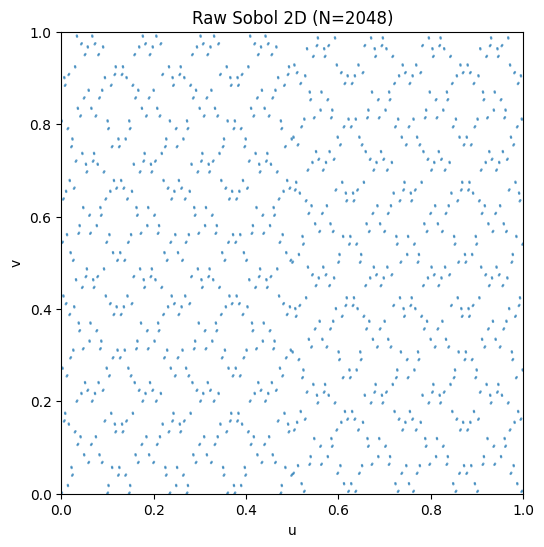

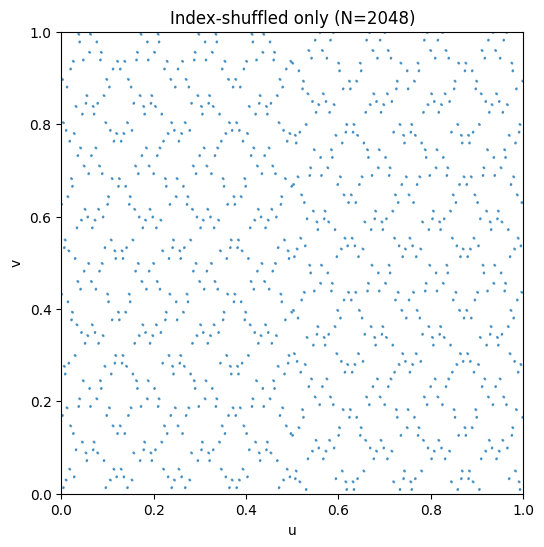

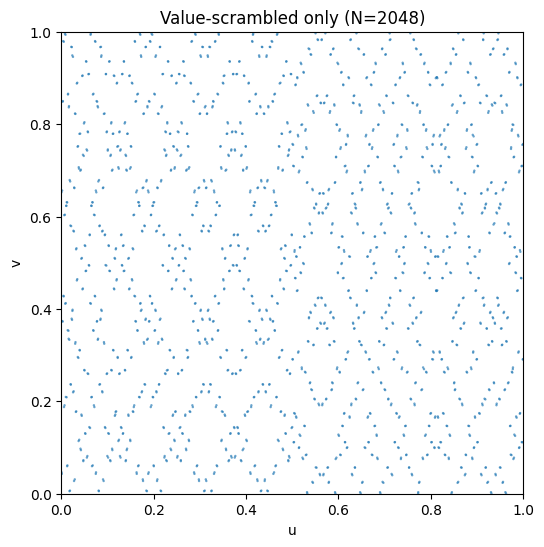

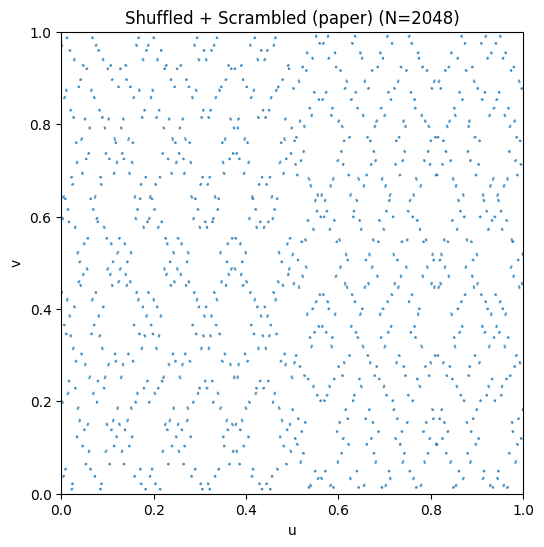

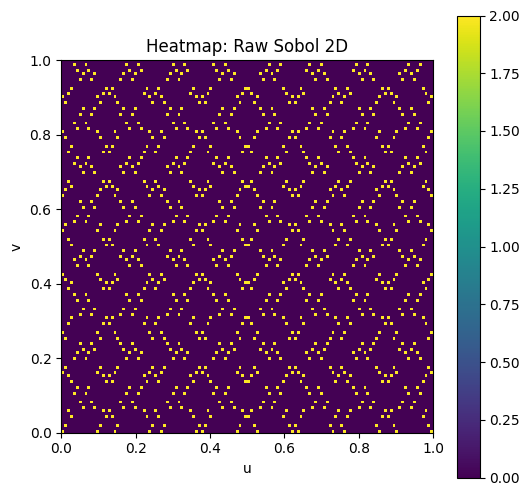

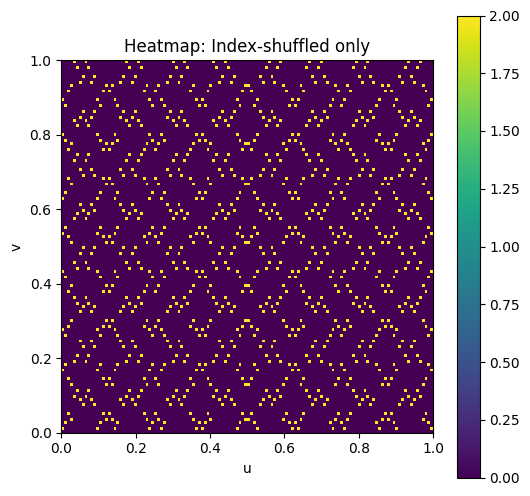

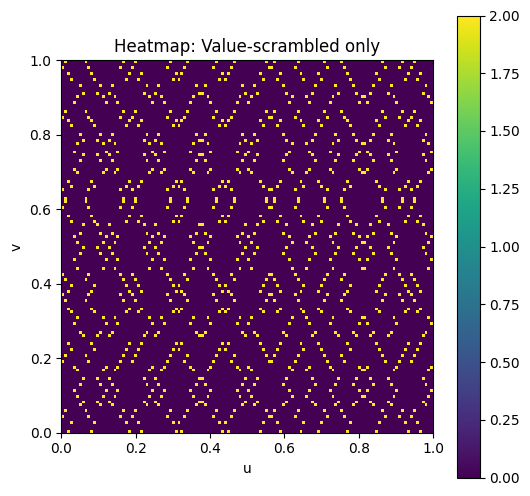

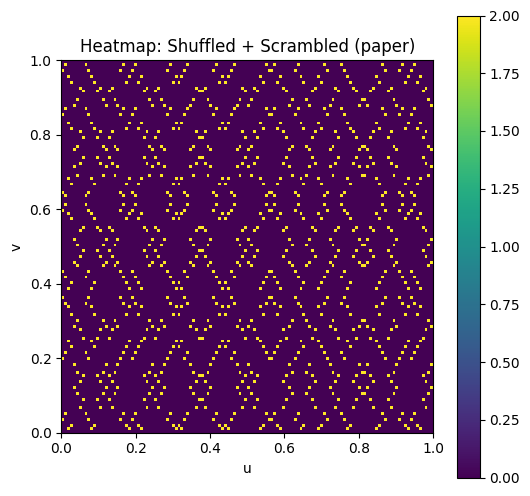

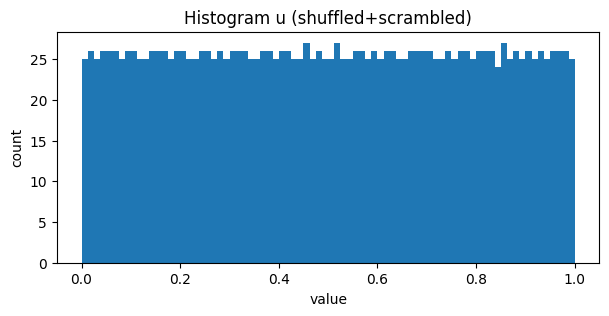

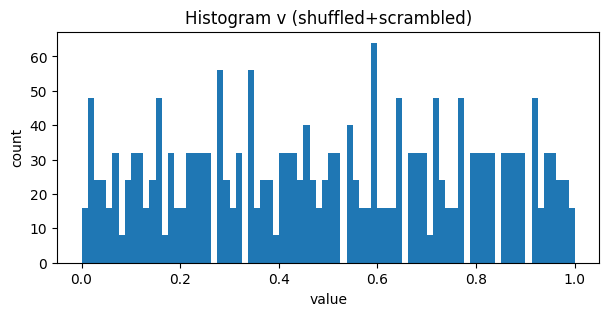

In [12]:
sobol_direction_nums = sobol_direction_numbers_2d()

def collect_uv(N, fn_u32):
    u = np.empty(N, dtype=np.float64)
    v = np.empty(N, dtype=np.float64)
    for i in range(N):
        a,b = fn_u32(i)
        u[i] = u32_to_unit_float(a)
        v[i] = u32_to_unit_float(b)
    return u,v

def make_stage_fns(pixel_id, frame, bounce,
                   sobol_u32, nus_u32, hash_combine):

    seed_base = hash_combine(pixel_id, frame, bounce)

    def raw(si):
        return sobol_u32(0, si, sobol_direction_nums), sobol_u32(1, si, sobol_direction_nums)

    def shuffled(si):
        idx = nus_u32(si, seed_base)
        return sobol_u32(0, idx, sobol_direction_nums), sobol_u32(1, idx, sobol_direction_nums)

    def scrambled(si):
        x0, x1 = sobol_u32(0, si, sobol_direction_nums), sobol_u32(1, si, sobol_direction_nums)
        s0 = hash_combine(seed_base, 0)
        s1 = hash_combine(seed_base, 1)
        return nus_u32(x0, s0), nus_u32(x1, s1)

    def both(si):
        idx = nus_u32(si, seed_base)
        x0, x1 = sobol_u32(0, idx, sobol_direction_nums), sobol_u32(1, idx, sobol_direction_nums)
        s0 = hash_combine(seed_base, 0)
        s1 = hash_combine(seed_base, 1)
        return nus_u32(x0, s0), nus_u32(x1, s1)

    return raw, shuffled, scrambled, both

def plot_stages(N, pixel_id, frame, bounce,
                sobol_u32, nus_u32, hash_combine):

    raw, shuffled, scrambled, both = make_stage_fns(
        pixel_id, frame, bounce, sobol_u32, nus_u32, hash_combine
    )

    u_raw, v_raw = collect_uv(N, raw)
    u_shf, v_shf = collect_uv(N, shuffled)
    u_scr, v_scr = collect_uv(N, scrambled)
    u_both,v_both= collect_uv(N, both)

    scatter01(u_raw,  v_raw,  f"Raw Sobol 2D (N={N})")
    scatter01(u_shf,  v_shf,  f"Index-shuffled only (N={N})")
    scatter01(u_scr,  v_scr,  f"Value-scrambled only (N={N})")
    scatter01(u_both, v_both, f"Shuffled + Scrambled (paper) (N={N})")

    heatmap01(u_raw,  v_raw,  "Heatmap: Raw Sobol 2D")
    heatmap01(u_shf,  v_shf,  "Heatmap: Index-shuffled only")
    heatmap01(u_scr,  v_scr,  "Heatmap: Value-scrambled only")
    heatmap01(u_both, v_both, "Heatmap: Shuffled + Scrambled (paper)")

    hist01(u_both, "Histogram u (shuffled+scrambled)")
    hist01(v_both, "Histogram v (shuffled+scrambled)")

plot_stages(
    N=2048,
    pixel_id=123,
    frame=0,
    bounce=0,
    sobol_u32=sobol_u32_stateless,                 # your function
    nus_u32=nested_uniform_scramble,           # your function
    hash_combine=hash_combine
)


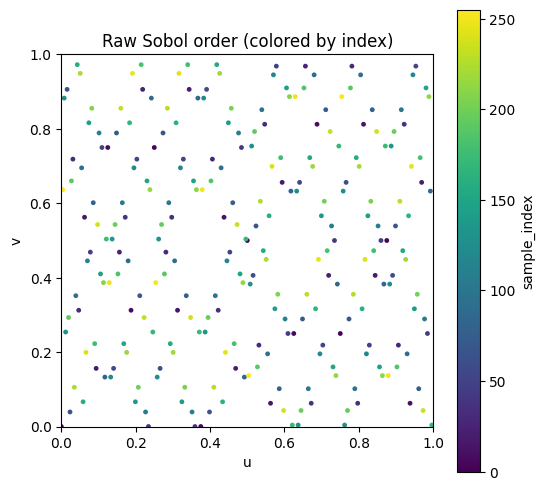

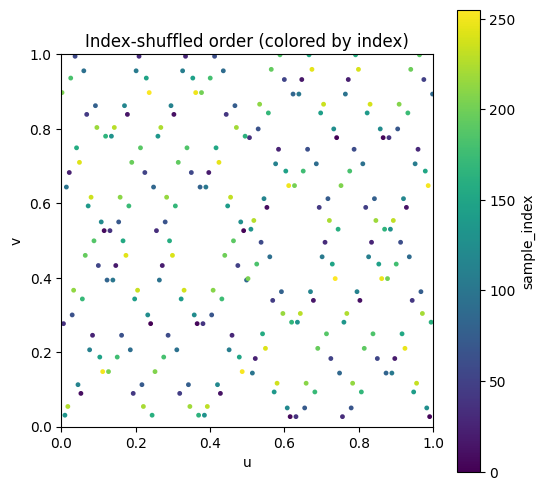

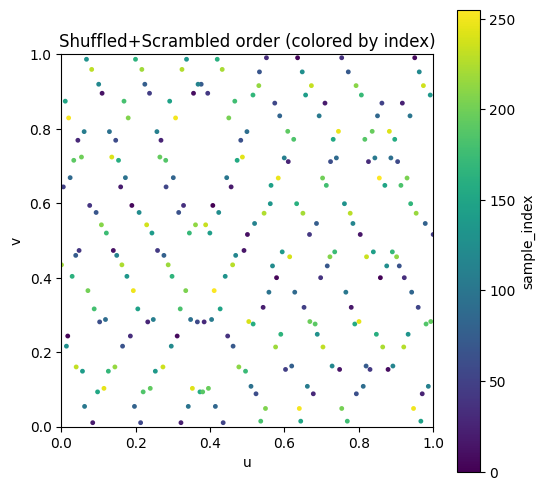

In [13]:
def scatter_color_by_index(u, v, title):
    plt.figure(figsize=(6,6))
    plt.scatter(u, v, c=np.arange(len(u)), s=12, edgecolor="none")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.xlabel("u"); plt.ylabel("v")
    plt.colorbar(label="sample_index")
    plt.show()

def plot_order_effect(N, pixel_id, frame, bounce, sobol_u32, nus_u32, hash_combine):
    raw, shuffled, _, both = make_stage_fns(pixel_id, frame, bounce, sobol_u32, nus_u32, hash_combine)
    u_raw, v_raw = collect_uv(N, raw)
    u_shf, v_shf = collect_uv(N, shuffled)
    u_b, v_b     = collect_uv(N, both)

    scatter_color_by_index(u_raw, v_raw, "Raw Sobol order (colored by index)")
    scatter_color_by_index(u_shf, v_shf, "Index-shuffled order (colored by index)")
    scatter_color_by_index(u_b,   v_b,   "Shuffled+Scrambled order (colored by index)")

plot_order_effect(256, 123, 0, 0, sobol_u32_stateless, nested_uniform_scramble, hash_combine)


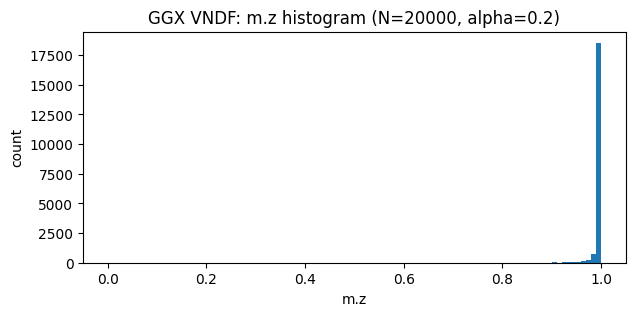

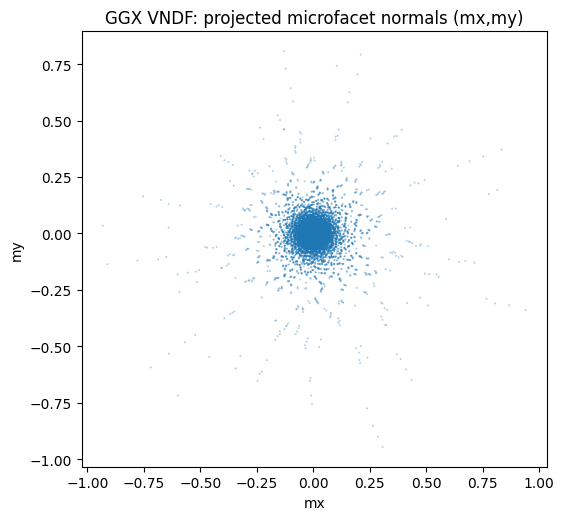

In [14]:
def plot_ggx(N, pixel_id, frame, bounce, V, alpha,
             sobol_u32, nus_u32, hash_combine, sample_ggx_vndf):

    seed_base = hash_combine(pixel_id, frame, bounce)

    mx = np.empty(N); my = np.empty(N); mz = np.empty(N)
    for i in range(N):
        # full paper sampler
        idx = nus_u32(i, seed_base)
        x0, x1 = sobol_u32(0, idx, sobol_direction_nums), sobol_u32(1, idx, sobol_direction_nums)
        u0 = nus_u32(x0, hash_combine(seed_base, 0))
        u1 = nus_u32(x1, hash_combine(seed_base, 1))

        m = sample_ggx_vndf(u32_to_unit_float(u0), u32_to_unit_float(u1), V, alpha)
        mx[i], my[i], mz[i] = m

    # mz histogram
    plt.figure(figsize=(7,3))
    plt.hist(mz, bins=100, range=(0,1))
    plt.title(f"GGX VNDF: m.z histogram (N={N}, alpha={alpha})")
    plt.xlabel("m.z"); plt.ylabel("count")
    plt.show()

    # projected normals
    plt.figure(figsize=(6,6))
    plt.scatter(mx, my, s=2, alpha=0.35, edgecolor="none")
    plt.gca().set_aspect("equal")
    plt.title("GGX VNDF: projected microfacet normals (mx,my)")
    plt.xlabel("mx"); plt.ylabel("my")
    plt.show()

V = np.array([0.2, -0.3, 0.93], dtype=np.float64)
V /= np.linalg.norm(V)
plot_ggx(20000, 123, 0, 0, V, alpha=0.2,
         sobol_u32=sobol_u32_stateless,
         nus_u32=nested_uniform_scramble,
         hash_combine=hash_combine,
         sample_ggx_vndf=sample_ggx_vndf)


In [15]:
def auto_limits(x, y, pct=99.5, pad=1.1):
    ax = np.percentile(np.abs(x), pct)
    ay = np.percentile(np.abs(y), pct)
    r = max(ax, ay) * pad
    if r == 0: r = 1.0
    return (-r, r), (-r, r)

def scatter_cloud(mx, my, title="", pct=99.5, s=2):
    (xmin, xmax), (ymin, ymax) = auto_limits(mx, my, pct=pct)
    plt.figure(figsize=(5.5,5.5))
    plt.scatter(mx, my, s=s, alpha=0.25, edgecolor="none")
    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.3)
    plt.xlabel("mx"); plt.ylabel("my")
    plt.title(title)
    plt.show()

def hist01(x, title="", bins=80):
    plt.figure(figsize=(6,3))
    plt.hist(x, bins=bins, range=(0,1), alpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.xlabel("value"); plt.ylabel("count")
    plt.title(title)
    plt.show()

def hist_zoom(x, title="", bins=80, lo=0.9, hi=1.0):
    plt.figure(figsize=(6,3))
    plt.hist(x, bins=bins, range=(lo,hi), alpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.xlabel("value"); plt.ylabel("count")
    plt.title(title + f" (zoom {lo}..{hi})")
    plt.show()

In [16]:
def rotate_xy_to_V(mx, my, V):
    # rotate (mx,my) so that V's projection aligns with +x
    V = normalize(V)
    ang = np.arctan2(V[1], V[0])  # angle of V projection
    c, s = np.cos(-ang), np.sin(-ang)
    x = c*mx - s*my
    y = s*mx + c*my
    return x, y

def density2d(mx, my, title="", pct=99.7, bins=200):
    (xmin,xmax),(ymin,ymax) = auto_limits(mx, my, pct=pct)
    plt.figure(figsize=(5.5,5.5))
    plt.hist2d(mx, my, bins=bins, range=[[xmin,xmax],[ymin,ymax]])
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(False)
    plt.xlabel("mx"); plt.ylabel("my")
    plt.title(title)
    plt.show()

def sample_cloud(sample_fn, N, V, roughness, u01_provider):
    # u01_provider() must return (u1,u2) floats in [0,1)
    mx = np.empty(N); my = np.empty(N); mz = np.empty(N)
    for i in range(N):
        u1,u2 = u01_provider()
        m = sample_fn(u1, u2, V, roughness)
        mx[i], my[i], mz[i] = m[0], m[1], m[2]
    return mx,my,mz

# example u01 provider using numpy RNG (swap in your shuffled+scrambled sobol later)
rng = np.random.default_rng(0)
def u01_rng():
    return float(rng.random()), float(rng.random())

def plot_vndf_suite(sample_fn, N=20000, roughness=0.2, V=(0,0,1), u01_provider=u01_rng):
    V = normalize(V)
    mx,my,mz = sample_cloud(sample_fn, N, V, roughness, u01_provider)

    rx, ry = rotate_xy_to_V(mx, my, V)
    density2d(rx, ry, title=f"VNDF rotated cloud (mx,my) V={V} rough={roughness}", pct=99.7)
    # scatter_cloud(rx, ry, title=f"VNDF rotated cloud (mx,my) V={V} rough={roughness}", pct=99.7, s=2)
    # scatter_cloud(mx, my, title=f"VNDF cloud (mx,my)  V={V}  rough={roughness}", pct=99.7, s=2)
    # hist01(mz, title=f"m.z histogram (0..1)  V={V}  rough={roughness}", bins=80)
    # hist_zoom(mz, title=f"m.z histogram", bins=80, lo=0.95, hi=1.0)

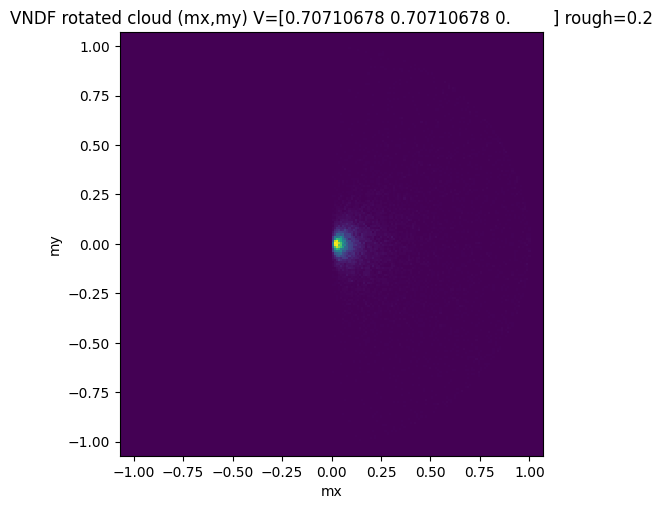

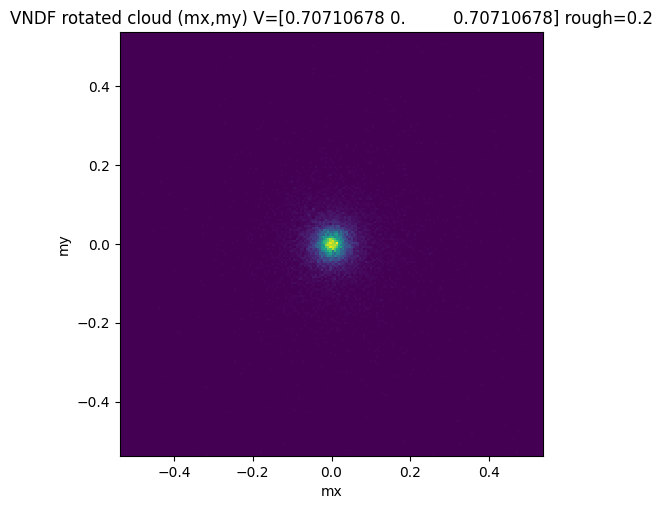

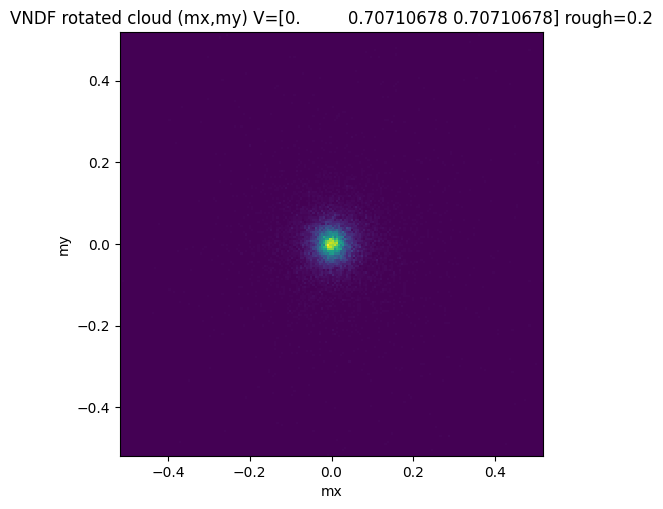

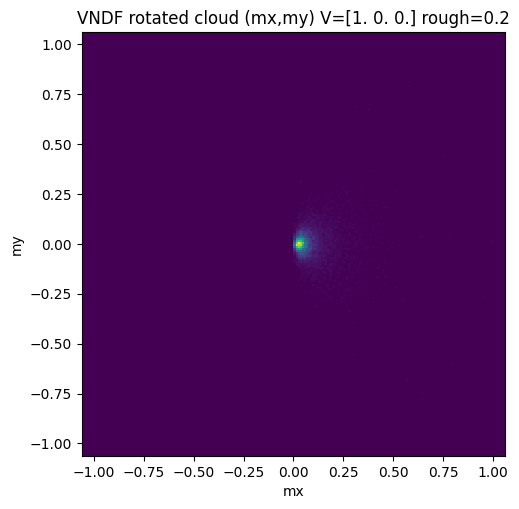

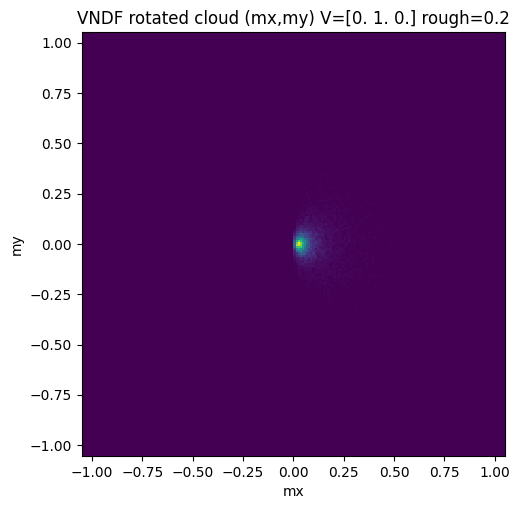

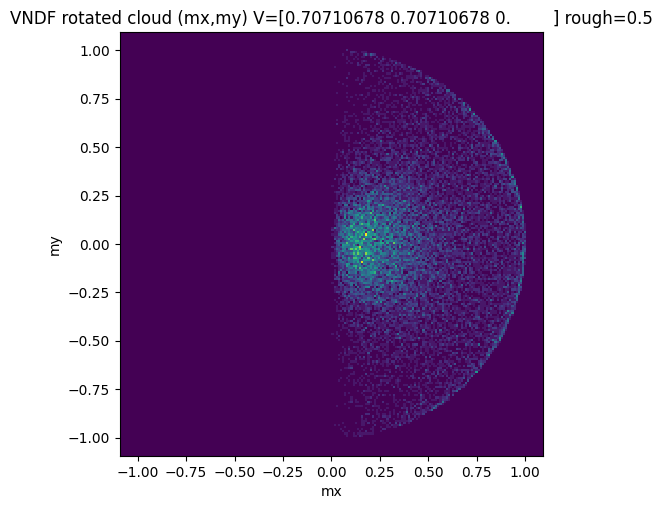

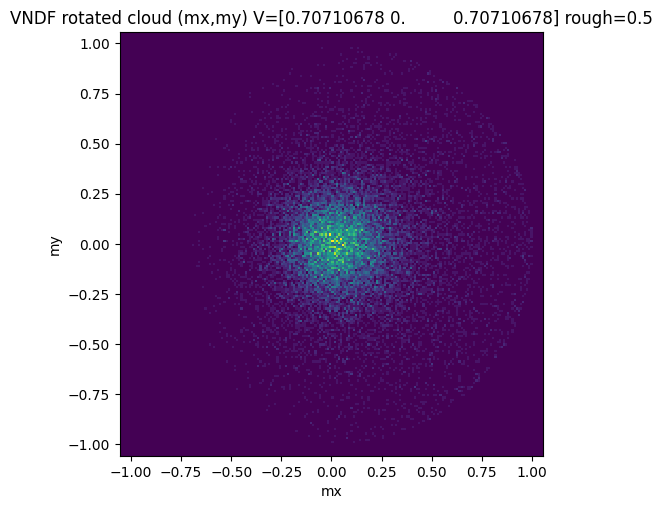

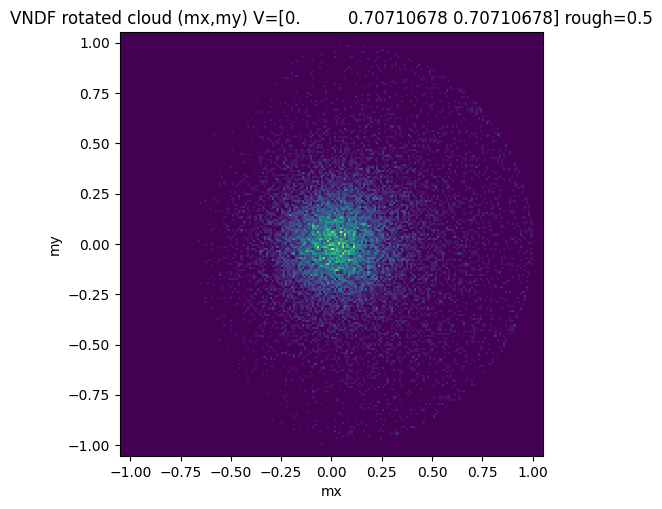

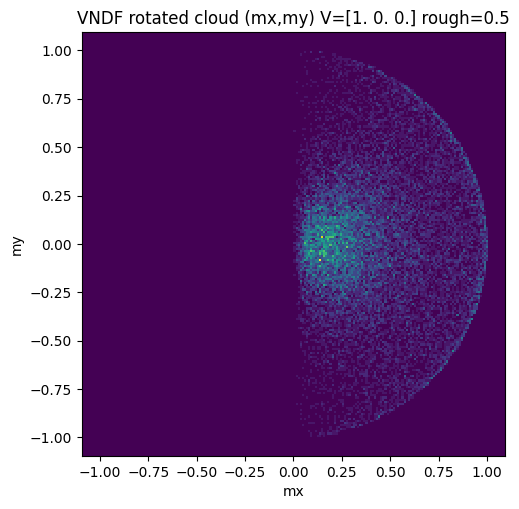

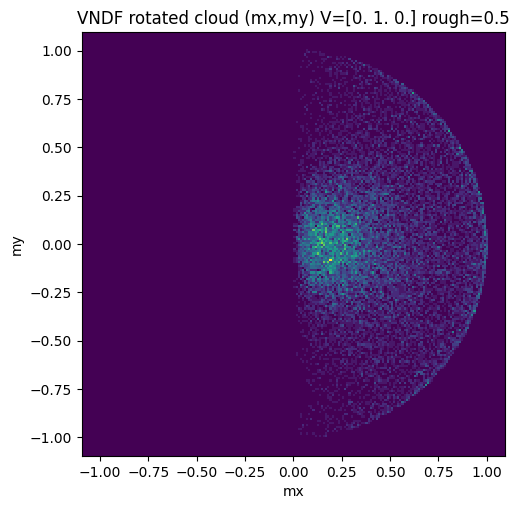

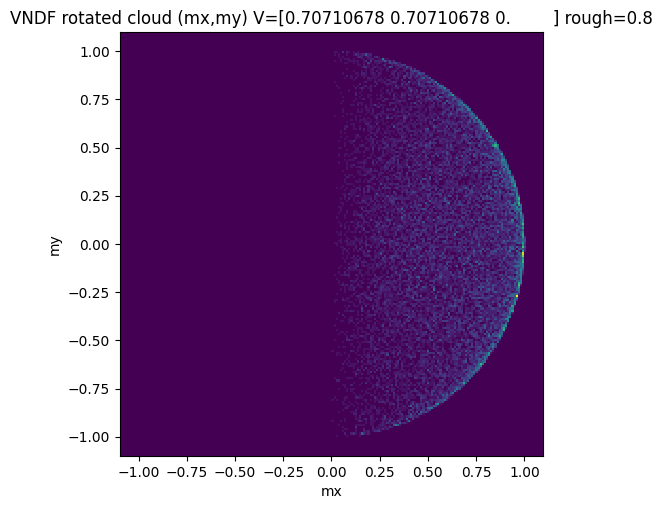

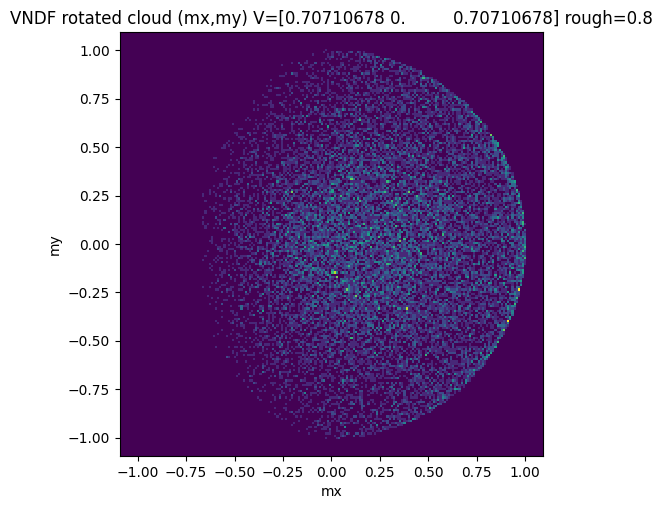

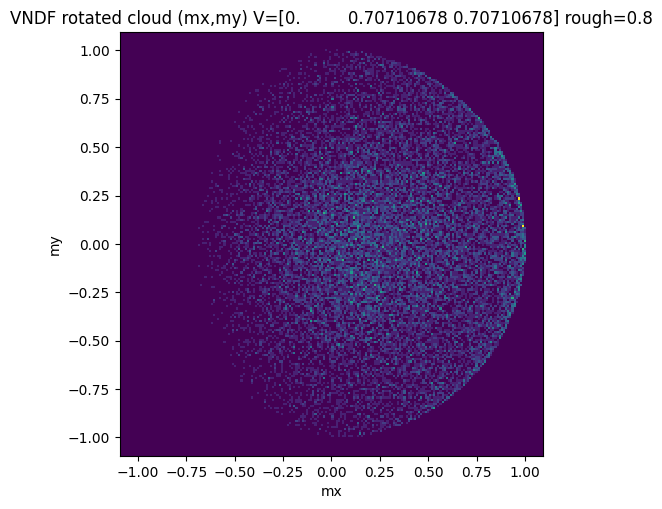

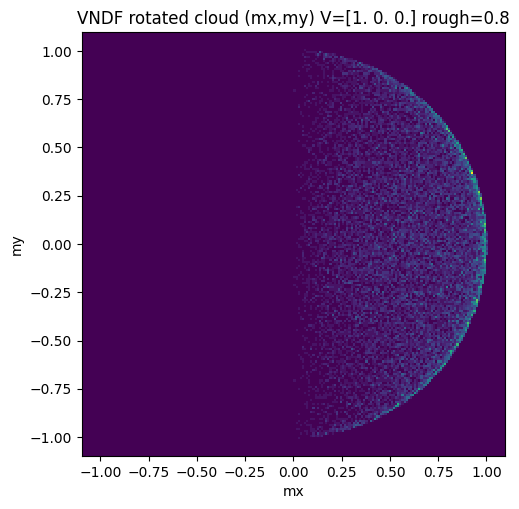

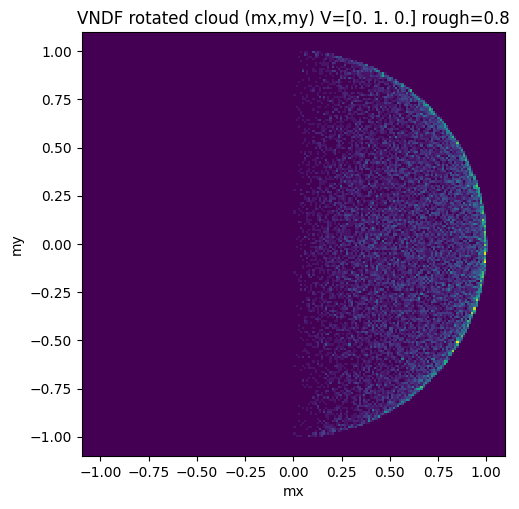

In [17]:
# Try a grid of V and roughness
for rough in [0.2, 0.5, 0.8]:
    for V in [(0.9, 0.9, 0.0), (0.9,0.0,0.9), (0.0,0.9,0.9), (0.9,0.0,0.0), (0.0,0.9,0.0)]:
        plot_vndf_suite(sample_ggx_vndf, N=20000, roughness=rough, V=V, u01_provider=u01_rng)

In [18]:
## EXAMPLE USAGE

def render_pixedl(pixel_id, frame, spp=65536, max_bounces=100):
    for bounce in range(max_bounces):
        seed_base = hash_combine([pixel_id, frame, bounce])
        for sample_index in range(spp):
            u0, u1 = shuffled_scrambled_sobol2d(sample_index, seed_base)
            #wi = sample_ggx_vndf(u0, u1)
            #trace_ray(wi)

In [ ]:
# CPU BENCHMARK: 1M GGX VNDF samples
import time

N_BENCH = 1_000_000
pixel_id, frame, bounce = 123, 0, 0
roughness = 0.5
V = np.array([0.2, -0.3, 0.93], dtype=np.float64)
V /= np.linalg.norm(V)
Vx, Vy, Vz = float(V[0]), float(V[1]), float(V[2])

if 'sobol_direction_nums' not in globals():
    sobol_direction_nums = sobol_direction_numbers_2d()
dirs0 = tuple(int(x) for x in sobol_direction_nums[0])
dirs1 = tuple(int(x) for x in sobol_direction_nums[1])

seed_base = hash_combine(pixel_id, frame, bounce)
scr_seed0 = hash_combine(seed_base, 0)
scr_seed1 = hash_combine(seed_base, 1)

scr = nested_uniform_scramble_fast
sobol_fast = sobol_u32_fast_from_dirs
sample_fast = sample_ggx_vndf_fast
scale = INV_FRAC_ONE

t0 = time.perf_counter()
checksum = 0.0
for i in range(N_BENCH):
    idx = scr(i, seed_base)
    x0 = sobol_fast(idx, dirs0)
    x1 = sobol_fast(idx, dirs1)

    u0 = scr(x0, scr_seed0)
    u1 = scr(x1, scr_seed1)

    _, _, mz = sample_fast(u0 * scale, u1 * scale, Vx, Vy, Vz, roughness)
    checksum += mz
elapsed = time.perf_counter() - t0

samples_per_sec = N_BENCH / elapsed
us_per_sample = (elapsed / N_BENCH) * 1e6

print(f'CPU benchmark (optimized full path): {N_BENCH:,} GGX VNDF samples')
print(f'Elapsed: {elapsed:.3f} s')
print(f'Throughput: {samples_per_sec:,.0f} samples/s')
print(f'Latency: {us_per_sample:.3f} us/sample')
print(f'checksum(m.z): {checksum:.6f}')


In [ ]:
# CPU BENCHMARK: 1M GGX VNDF math-only samples
import time

N_BENCH_MATH = 1_000_000
roughness = 0.5
V = np.array([0.2, -0.3, 0.93], dtype=np.float64)
V /= np.linalg.norm(V)
Vx, Vy, Vz = float(V[0]), float(V[1]), float(V[2])

rng = np.random.default_rng(12345)
u1_list = rng.random(N_BENCH_MATH, dtype=np.float64).tolist()
u2_list = rng.random(N_BENCH_MATH, dtype=np.float64).tolist()
sample_fast = sample_ggx_vndf_fast

t0 = time.perf_counter()
checksum_math = 0.0
for u1, u2 in zip(u1_list, u2_list):
    _, _, mz = sample_fast(u1, u2, Vx, Vy, Vz, roughness)
    checksum_math += mz
elapsed_math = time.perf_counter() - t0

samples_per_sec_math = N_BENCH_MATH / elapsed_math
us_per_sample_math = (elapsed_math / N_BENCH_MATH) * 1e6

print(f'CPU benchmark (optimized math-only): {N_BENCH_MATH:,} GGX VNDF samples')
print(f'Elapsed: {elapsed_math:.3f} s')
print(f'Throughput: {samples_per_sec_math:,.0f} samples/s')
print(f'Latency: {us_per_sample_math:.3f} us/sample')
print(f'checksum(m.z): {checksum_math:.6f}')


In [ ]:
# RANDOM POINT CLOUD PLOT (UNIT SQUARE)
N_POINTS = 50000
seed = 2026
rng = np.random.default_rng(seed)

pts = rng.random((N_POINTS, 2), dtype=np.float64)
x = pts[:, 0]
y = pts[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=2, alpha=0.35, edgecolors='none')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, alpha=0.25)
plt.title(f'Random Points in [0,1]^2 (N={N_POINTS:,}, seed={seed})')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Publication Figures

In [ ]:

# ── Figure 1: Stratification comparison (4-panel) ────────────────────────────
# Shows why shuffled+scrambled Sobol is better than uniform random and raw Sobol.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

N_SCATTER = 2048
pixel_id, frame, bounce = 123, 0, 0
seed_base = hash_combine(pixel_id, frame, bounce)
scr_seed0 = hash_combine(seed_base, 0)
scr_seed1 = hash_combine(seed_base, 1)
dirs = sobol_direction_numbers_2d()

# ── collect samples for each strategy ────────────────────────────────────────
def _collect(n, fn):
    u = np.empty(n); v = np.empty(n)
    for i in range(n):
        a, b = fn(i)
        u[i] = u32_to_unit_float(a)
        v[i] = u32_to_unit_float(b)
    return u, v

rng_fig = np.random.default_rng(42)
u_rnd = rng_fig.random(N_SCATTER)
v_rnd = rng_fig.random(N_SCATTER)

u_raw, v_raw = _collect(N_SCATTER, lambda i: (
    sobol_u32_stateless(0, i, dirs),
    sobol_u32_stateless(1, i, dirs)))

u_scr, v_scr = _collect(N_SCATTER, lambda i: (
    nested_uniform_scramble(sobol_u32_stateless(0, i, dirs), scr_seed0),
    nested_uniform_scramble(sobol_u32_stateless(1, i, dirs), scr_seed1)))

u_both, v_both = _collect(N_SCATTER, lambda i: (
    nested_uniform_scramble(sobol_u32_stateless(0, nested_uniform_scramble(i, seed_base), dirs), scr_seed0),
    nested_uniform_scramble(sobol_u32_stateless(1, nested_uniform_scramble(i, seed_base), dirs), scr_seed1)))

# ── plot ──────────────────────────────────────────────────────────────────────
TITLES = [
    "Uniform Random",
    "Raw Sobol",
    "Scrambled (value only)",
    "Shuffled + Scrambled\n(hardware implementation)",
]
DATA = [(u_rnd, v_rnd), (u_raw, v_raw), (u_scr, v_scr), (u_both, v_both)]
COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (u, v), title, color in zip(axes, DATA, TITLES, COLORS):
    ax.scatter(u, v, s=1.4, alpha=0.55, color=color, edgecolors="none", rasterized=True)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlabel("$u_1$", fontsize=8); ax.set_ylabel("$u_2$", fontsize=8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.suptitle(f"2D Sample Stratification Comparison  (N = {N_SCATTER:,})",
             fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig("fig_stratification.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_stratification.png")


In [ ]:

# ── Figure 2: GGX VNDF output distribution (3 roughness values) ──────────────
# Validates that the hardware sampler produces the correct GGX distribution.
# Shows projected microfacet normals (mx, my) for alpha = 0.1, 0.4, 0.8.

import math

N_GGX = 20_000
V = normalize(np.array([0.2, -0.3, 0.93]))
ALPHAS = [0.1, 0.4, 0.8]
ALPHA_LABELS = [r"$\alpha = 0.1$  (smooth)", r"$\alpha = 0.4$  (medium)", r"$\alpha = 0.8$  (rough)"]

def _ggx_samples(N, V, alpha, seed_base):
    dirs = sobol_direction_numbers_2d()
    scr0 = hash_combine(seed_base, 0)
    scr1 = hash_combine(seed_base, 1)
    mx = np.empty(N); my = np.empty(N); mz = np.empty(N)
    for i in range(N):
        idx = nested_uniform_scramble_fast(i, seed_base)
        x0 = sobol_u32_stateless(0, idx, dirs)
        x1 = sobol_u32_stateless(1, idx, dirs)
        u0 = nested_uniform_scramble_fast(x0, scr0)
        u1 = nested_uniform_scramble_fast(x1, scr1)
        m = sample_ggx_vndf(u0 * INV_FRAC_ONE, u1 * INV_FRAC_ONE, V, alpha)
        mx[i], my[i], mz[i] = m[0], m[1], m[2]
    return mx, my, mz

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

for ax, alpha, label in zip(axes, ALPHAS, ALPHA_LABELS):
    sb = hash_combine(123, 0, 0)
    mx, my, mz = _ggx_samples(N_GGX, V, alpha, sb)

    # 2D density
    lim = max(np.percentile(np.abs(mx), 99.5), np.percentile(np.abs(my), 99.5)) * 1.1
    lim = max(lim, 0.05)
    bins = 120
    h, xe, ye = np.histogram2d(mx, my, bins=bins, range=[[-lim, lim], [-lim, lim]])
    ax.imshow(h.T, origin="lower", extent=[-lim, lim, -lim, lim],
              aspect="equal", cmap="inferno", interpolation="bilinear")
    # mark view projection
    ax.axhline(0, color="white", lw=0.4, alpha=0.4)
    ax.axvline(0, color="white", lw=0.4, alpha=0.4)
    vx_proj, vy_proj = float(V[0]), float(V[1])
    ax.annotate("", xy=(vx_proj*lim*0.55, vy_proj*lim*0.55), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="cyan", lw=1.2))
    ax.set_title(label, fontsize=9, pad=4)
    ax.set_xlabel("$h_x$", fontsize=8); ax.set_ylabel("$h_y$", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(f"GGX VNDF Output Distribution  (N = {N_GGX:,} samples,  view direction indicated by arrow)",
             fontsize=9.5, y=1.01)
fig.tight_layout()
fig.savefig("fig_ggx_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_ggx_distribution.png")
